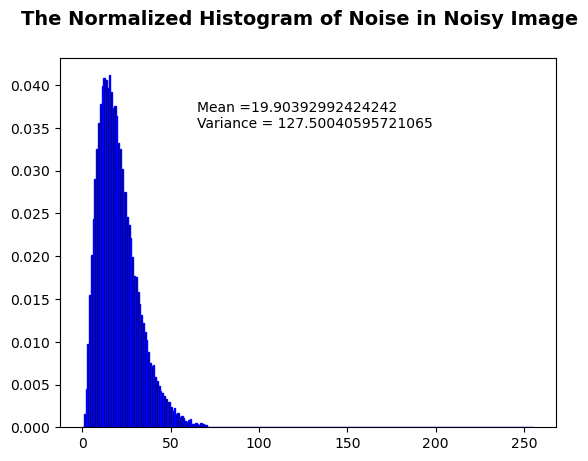

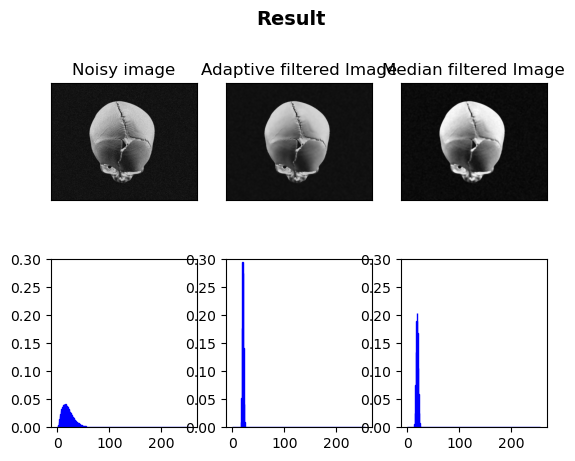

In [12]:
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt
img  = cv.imread('noisy_skull.png', cv.IMREAD_GRAYSCALE)
h, w = img.shape

sample_noise = img[:512, :165]
snh, snw = sample_noise.shape

nhistval = cv.calcHist([sample_noise],[0],None,[256],[0,256])/(snh*snw)
nmean = 0
nvariance = 0
s=0

for i in np.arange(256) :
    s = float(nhistval[i]*i)
    nmean = s+nmean

s = 0
for i in np.arange(256) :
    s = float(nhistval[i]*((i-nmean)**2))
    nvariance = s+nvariance
 
fig1 = plt.figure()
fig1.suptitle("The Normalized Histogram of Noise in Noisy Image", fontsize=14, fontweight='bold')
nax = fig1.add_subplot(111)
nax.text(65, 0.035, r'Mean ='+str(nmean)+'\nVariance = '+str(nvariance) , fontsize=10)
noisehist = plt.hist(sample_noise.ravel(),density=True  , bins=256, range=(0 , 255), fc='k', ec='b')
plt.show()

pimg = cv.copyMakeBorder(img,4,4,4,4,cv.BORDER_REPLICATE)
ph , pw = pimg.shape[::]
meanmat = np.zeros((h , w))
varmat = np.zeros((h , w))

for i in np.arange(ph-8):
    for j in np.arange(pw-8):
        temp = pimg[0+i:9+i , 0+j:9+j]
        meant = temp.mean()
        vart = temp.var()
        meanmat[i , j] = meant
        varmat[i , j] = vart

vmean = varmat.mean()
for i in np.arange(ph-8):
    for j in np.arange(pw-8):
        if vmean > varmat[i , j] :
            varmat[i , j] = vmean

fimg = np.zeros((h , w))
for i in np.arange(ph-8):
    for j in np.arange(pw-8):
        fimg[i , j] = img[i , j] - ((vmean/varmat[i , j])*(img[i , j]-meanmat[i , j]))
        
adimg = np.uint8(fimg)
nadimg = adimg[ :512 ,  :165] 

medimg = cv.medianBlur(img,7)
nmedimg = medimg[ :512 ,  :165] 

fig2 = plt.figure("Result")
fig2.suptitle("Result", fontsize=14, fontweight='bold')

ax1 = fig2.add_subplot(231)
ax1.axes.get_xaxis().set_visible(False)
ax1.axes.get_yaxis().set_visible(False)
ax1.set_title('Noisy image')
ax1.imshow(img , cmap = 'gray')

ax2 = fig2.add_subplot(234)
plt.hist(sample_noise.ravel()  , density=True , bins=256, range=(0 , 255), fc='k', ec='b')
plt.ylim([0, 0.3])

ax3 = fig2.add_subplot(232)
ax3.axes.get_xaxis().set_visible(False)
ax3.axes.get_yaxis().set_visible(False)
ax3.set_title('Adaptive filtered Image')
ax3.imshow(adimg , cmap = 'gray')

ax4 = fig2.add_subplot(235)
plt.hist(nadimg.ravel()  , density=True , bins=256, range=(0 , 255), fc='k', ec='b')
plt.ylim([0, 0.3])

ax5 = fig2.add_subplot(233)
ax5.axes.get_xaxis().set_visible(False)
ax5.axes.get_yaxis().set_visible(False)
ax5.set_title('Median filtered Image')
ax5.imshow(medimg , cmap = 'gray')

ax6 = fig2.add_subplot(236)
plt.hist(nmedimg.ravel()  , density=True , bins=256, range=(0 , 255), fc='k', ec='b')
plt.ylim([0, 0.3])

plt.show()
